In [2]:
cd /content/drive/MyDrive/learning_work/churn_prediction/assets

/content/drive/MyDrive/learning_work/churn_prediction/assets


In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

In [4]:
demo = pd.read_csv("demo.csv")
card_info = pd.read_csv("card_info.csv")
cc_txn = pd.read_csv("cc_txn.csv")
sa_bal = pd.read_csv("sa_bal.csv")
dtxn = pd.read_csv("dtxn.csv")
y_train = pd.read_csv("y_train.csv")

print(demo.shape)
print(card_info.shape)
print(cc_txn.shape)
print(sa_bal.shape)
print(dtxn.shape)
print(y_train.shape)

(52762, 7)
(60296, 4)
(3223075, 5)
(633144, 3)
(490599, 4)
(494, 2)


In [38]:
def plot_graph(df, ind, lab, val):
  pivot_plot = df.pivot(index=ind, columns=lab,values=val).fillna(0).sort_index()
  # plot
  pivot_plot.plot(kind='line', marker='o', figsize=(10, 5))

  plt.title(f'Average of {val} by Month and Label')
  plt.xlabel('Month')
  plt.ylabel(f'Average of {val}')
  plt.xticks(ticks=range(len(pivot_plot.index)), labels=pivot_plot.index, rotation=45)
  plt.legend(title='Label')
  plt.grid(True, alpha=0.3)
  plt.tight_layout()
  plt.show()

## Demo

In [16]:
demo = demo.merge(y_train, on="user_id", how="right")
demo['label'] = demo['label'].astype(int)
print(demo.shape)
demo.head()

(494, 8)


,user_id,account_start_date,birth_year,gender,marital_status,family_income_segment_code,individual_income_segment_code,label
0,2723,1978-10-24,1938.0,F,2,,15,1
1,44088,1985-11-19,1952.0,M,,03,03,1
2,3139,1979-08-17,1951.0,F,3,04,08,0
3,25596,1969-07-04,1938.0,M,1,01,03,0
4,15409,1974-05-09,1947.0,M,,,14,0


In [28]:
demo['individual_income_segment_code'] = np.where(demo['individual_income_segment_code'] == '  ', '16', demo['individual_income_segment_code'])
demo['individual_income_segment_code'] = demo['individual_income_segment_code'].astype(str).astype(int).astype(str)
demo.head()

,user_id,account_start_date,birth_year,gender,marital_status,family_income_segment_code,individual_income_segment_code,label
0,2723,1978-10-24,1938.0,F,2,,15,1
1,44088,1985-11-19,1952.0,M,,03,3,1
2,3139,1979-08-17,1951.0,F,3,04,8,0
3,25596,1969-07-04,1938.0,M,1,01,3,0
4,15409,1974-05-09,1947.0,M,,,14,0


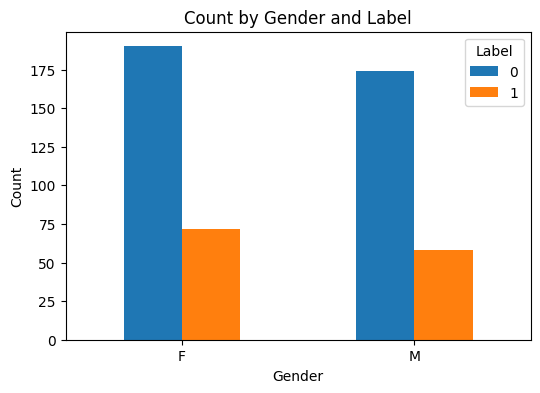

In [17]:
counts = demo[['gender','label']].value_counts()
plot_data = counts.unstack(fill_value=0)

# plot
ax = plot_data.plot(kind='bar', figsize=(6, 4))

plt.title('Count by Gender and Label')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Label')
plt.xticks(rotation=0)
plt.show()

In [30]:
demo[['individual_income_segment_code','label']].value_counts().reset_index().sort_values(by='individual_income_segment_code')

,individual_income_segment_code,label,count
29,1,1,4
11,1,0,19
26,10,1,7
9,10,0,23
30,11,1,3
14,11,0,17
25,12,1,8
13,12,0,17
15,13,0,16
18,13,1,11


## Card Info.

In [5]:
card_info = card_info.merge(y_train, on="user_id", how="right")
card_info['label'] = card_info['label'].astype(int)
print(card_info.shape)
card_info.head()

(556, 5)


,user_id,bill_cyc,cr_lmt_amt,card_no,label
0,2723,27.0,642000,3368,1
1,44088,15.0,1581000,51033,1
2,3139,14.0,524000,3861,0
3,25596,16.0,411000,30367,0
4,15409,15.0,796000,18746,0


## Credit tranaction

In [10]:
cc_txn = cc_txn.merge(y_train, on="user_id", how="right")
cc_txn['label'] = cc_txn['label'].astype(int)
cc_txn["txn_dt"] = pd.to_datetime(cc_txn["txn_dt"], errors="coerce")
cc_txn["year_month"] = cc_txn["txn_dt"].dt.to_period("M").astype(str)
cc_txn["month"] = cc_txn["txn_dt"].dt.month
print(cc_txn.shape)
cc_txn.head()

,mcc,txn_dt,user_id,txn_amt,card_no,label,year_month,month
0,mcc_cat11,2017-11-04,2723,125045.0,3368.0,1,2017-11,11
1,mcc_cat13,2017-10-13,2723,130143.0,3368.0,1,2017-10,10
2,mcc_cat16,2017-04-18,2723,24128.0,3368.0,1,2017-04,4
3,mcc_cat2,2017-08-07,2723,40044.0,3368.0,1,2017-08,8
4,mcc_cat12,2017-10-01,2723,54913.0,3368.0,1,2017-10,10


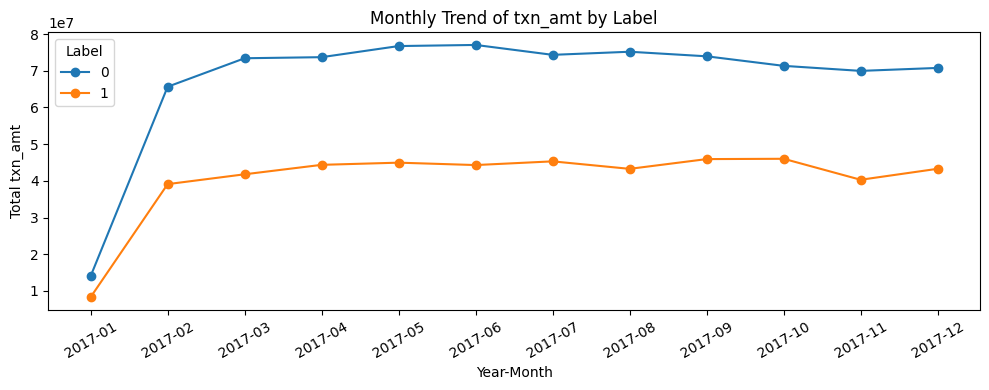

In [42]:
# รวม txn_amt รายเดือน แยกตาม label
trend = cc_txn.groupby(['year_month', 'label'])['txn_amt'].sum().reset_index()

# reshape ให้ง่ายต่อการ plot
trend_pivot = trend.pivot(index='year_month', columns='label',values='txn_amt').fillna(0)

# plot line chart
ax = trend_pivot.plot(kind='line', marker='o', figsize=(10, 4))

plt.title('Monthly Trend of txn_amt by Label')
plt.xlabel('Year-Month')
plt.ylabel('Total txn_amt')
plt.xticks(ticks=range(len(trend_pivot.index)), labels=trend_pivot.index, rotation=45)
plt.legend(title='Label')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

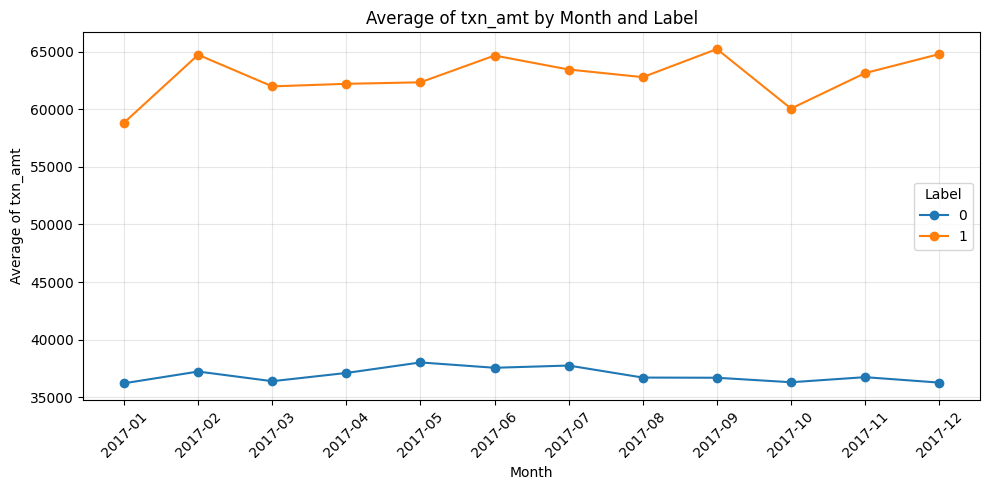

In [39]:
# รวม txn_amt รายเดือน แยกตาม label
trend = cc_txn.groupby(['year_month', 'label'])['txn_amt'].mean().reset_index()
plot_graph(trend, 'year_month', 'label', 'txn_amt')

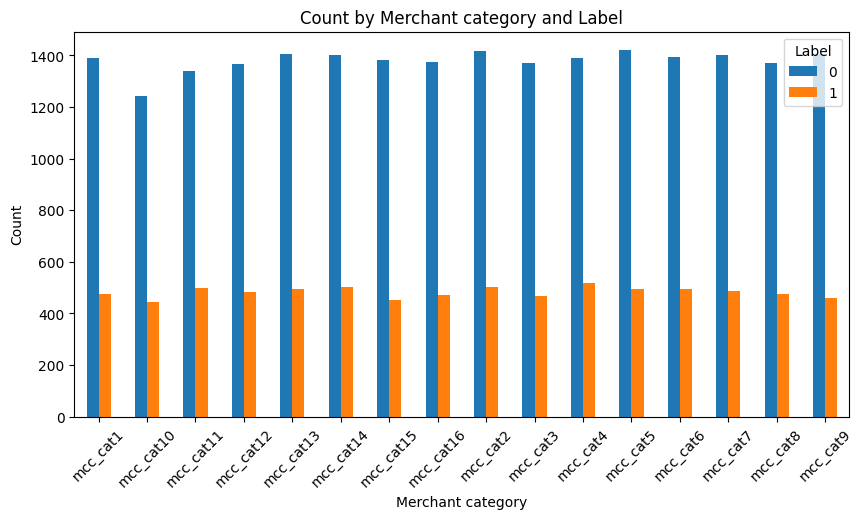

In [9]:
counts = cc_txn[['mcc','label']].value_counts()
plot_data = counts.unstack(fill_value=0)

# plot
ax = plot_data.plot(kind='bar', figsize=(10, 5))

plt.title('Count by Merchant category and Label')
plt.xlabel('Merchant category')
plt.ylabel('Count')
plt.legend(title='Label')
plt.xticks(rotation=45)
plt.show()

In [11]:
avg_month = cc_txn.groupby('year_month').agg(avg_txn_amt = ('txn_amt', 'mean')).reset_index()
avg_month

,year_month,avg_txn_amt
0,2017-01,42257.825758
1,2017-02,44252.203211
2,2017-03,42807.774433
3,2017-04,43743.733235
4,2017-05,44427.580869
5,2017-06,44349.130117
6,2017-07,44594.700708
7,2017-08,43277.965290
8,2017-09,44084.948143
9,2017-10,42970.332845


In [12]:
avg_cat = cc_txn.groupby('mcc').agg(avg_txn_amt = ('txn_amt', 'mean')).reset_index()
avg_cat

,mcc,avg_txn_amt
0,mcc_cat1,44497.403640
1,mcc_cat10,44468.779359
2,mcc_cat11,44748.616639
3,mcc_cat12,42547.007572
4,mcc_cat13,44592.960042
5,mcc_cat14,42669.338235
6,mcc_cat15,40979.269651
7,mcc_cat16,43329.129469
8,mcc_cat2,43347.454924
9,mcc_cat3,44450.999456


## Sa_bal

In [20]:
sa_bal = sa_bal.merge(y_train, on="user_id", how="right")
sa_bal['label'] = sa_bal['label'].astype(int)
print(sa_bal.shape)
sa_bal.head()

(5928, 4)


,user_id,mm,max_sa_bal,label
0,2723,1,716991.0,1
1,2723,10,236993.0,1
2,2723,11,0.0,1
3,2723,12,629437.0,1
4,2723,2,200357.0,1


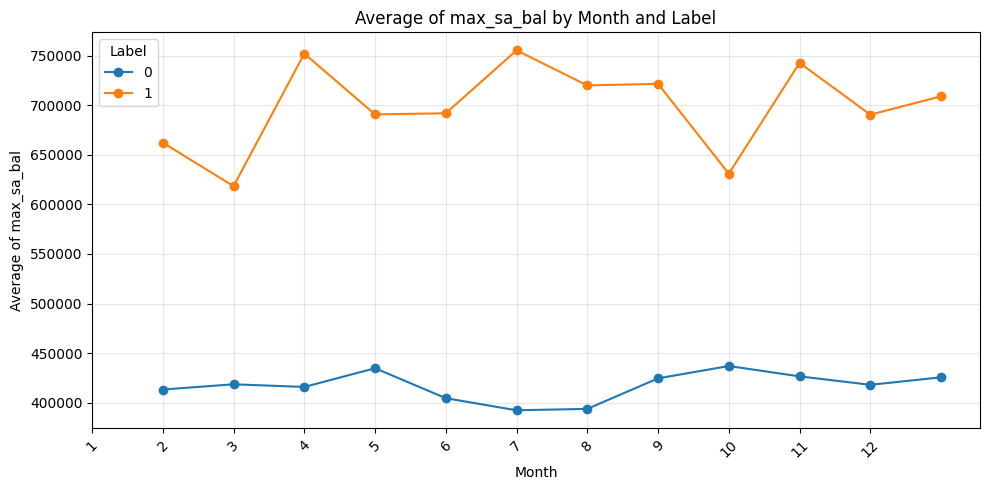

In [40]:
sa_agg = sa_bal.groupby(['mm', 'label']).agg(max_sa_bal = ('max_sa_bal', 'mean')).reset_index()
plot_graph(sa_agg, 'mm', 'label', 'max_sa_bal')

## In-Out account

In [28]:
dtxn = dtxn.merge(y_train, on="user_id", how="right")
dtxn['label'] = dtxn['label'].astype(int)
print(dtxn.shape)
dtxn.head()

(4649, 5)


,user_id,mm,amt_in,amt_out,label
0,2723,10,26114.0,128331.0,1
1,2723,11,0.0,54767.0,1
2,2723,2,72695.0,110524.0,1
3,2723,3,0.0,82986.0,1
4,2723,5,41468.0,47418.0,1


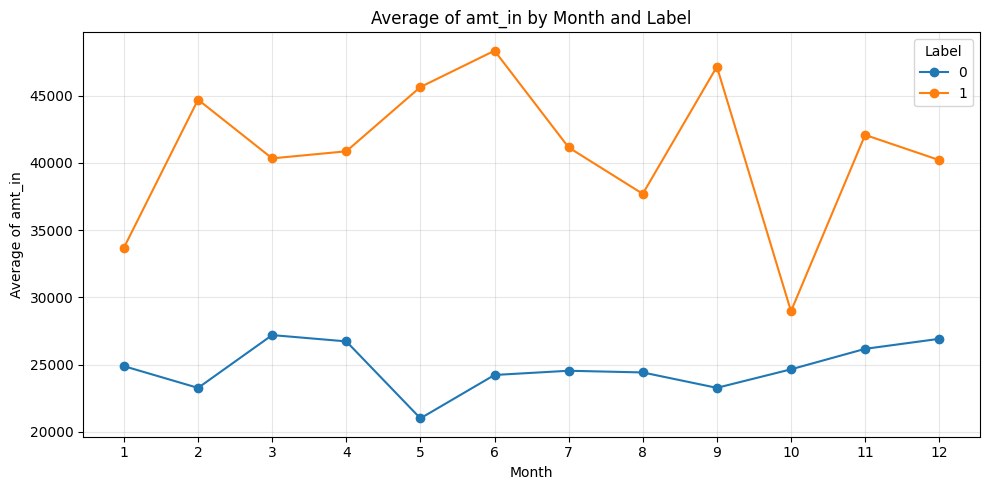

In [32]:
dtxn_agg = dtxn.groupby(['mm', 'label']).agg(amt_in = ('amt_in', 'mean')).reset_index()
plot_graph(dtxn_agg, 'mm', 'label', 'amt_in')

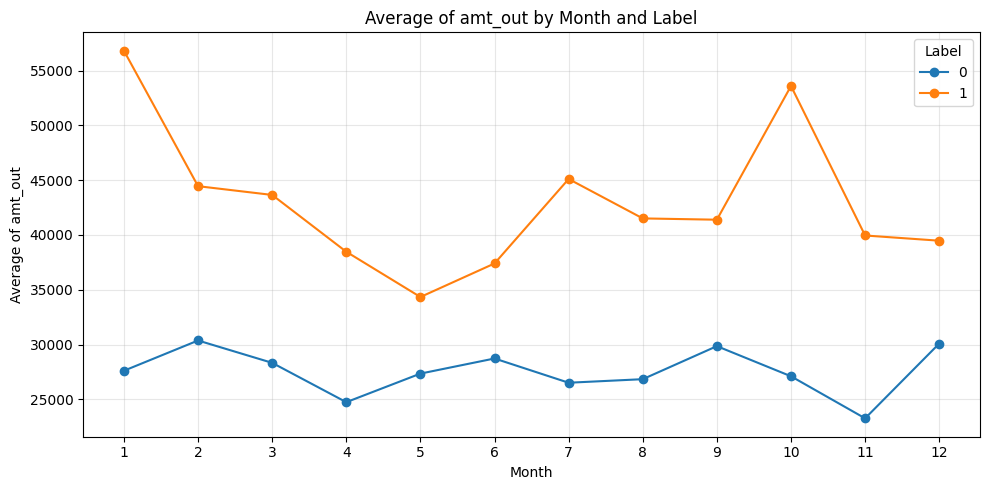

In [34]:
dtxn_agg = dtxn.groupby(['mm', 'label']).agg(amt_out = ('amt_out', 'mean')).reset_index()
plot_graph(dtxn_agg, 'mm', 'label', 'amt_out')

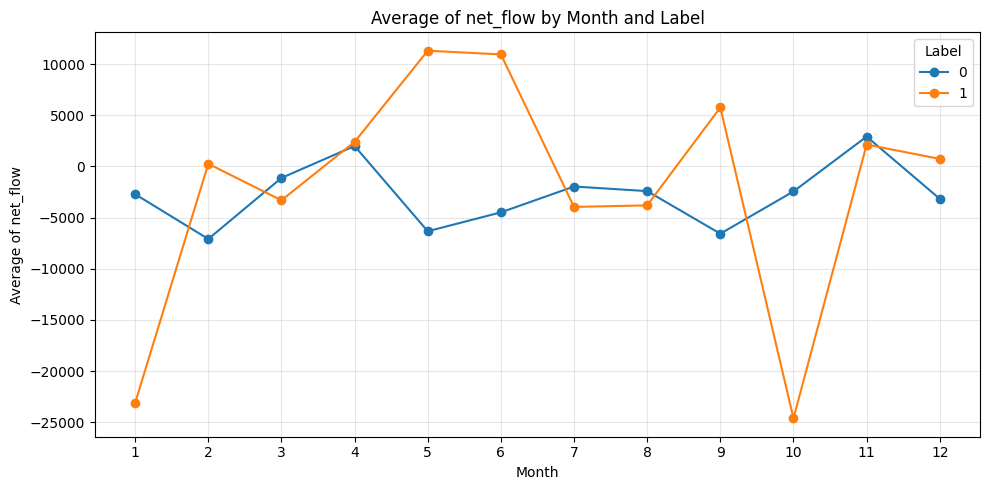

In [35]:
dtxn['net_flow'] = dtxn['amt_in'] - dtxn['amt_out']
dtxn_agg = dtxn.groupby(['mm', 'label']).agg(net_flow = ('net_flow', 'mean')).reset_index()
plot_graph(dtxn_agg, 'mm', 'label', 'net_flow')